In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

In [4]:
train_dir = "../data/train_images"
test_dir = "../data/test_images"
labels_path = "../data/train-labels.csv"

In [5]:
df = pd.read_csv(labels_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20000, 3)


,Unnamed: 0,image,text
0,0,train-0.png,BU522X
1,1,train-1.png,XQ8NE2
2,2,train-2.png,DTZD3E
3,3,train-3.png,SM424H
4,4,train-4.png,6YVTQR


In [6]:
df = pd.read_csv(labels_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20000, 3)


,Unnamed: 0,image,text
0,0,train-0.png,BU522X
1,1,train-1.png,XQ8NE2
2,2,train-2.png,DTZD3E
3,3,train-3.png,SM424H
4,4,train-4.png,6YVTQR


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  20000 non-null  int64 
 1   image       20000 non-null  object
 2   text        20000 non-null  object
dtypes: int64(1), object(2)
memory usage: 468.9+ KB
None


In [8]:
print(df.iloc[:10])

   Unnamed: 0        image    text
0           0  train-0.png  BU522X
1           1  train-1.png  XQ8NE2
2           2  train-2.png  DTZD3E
3           3  train-3.png  SM424H
4           4  train-4.png  6YVTQR
5           5  train-5.png  YV2C3D
6           6  train-6.png  XNBP7G
7           7  train-7.png  TGQXFU
8           8  train-8.png  36B667
9           9  train-9.png  QJ6HDR


In [9]:
df['label_length'] = df['text'].str.len()

print(df['label_length'].describe())

count    20000.000000
mean         6.000250
std          0.025495
min          6.000000
25%          6.000000
50%          6.000000
75%          6.000000
max          9.000000
Name: label_length, dtype: float64


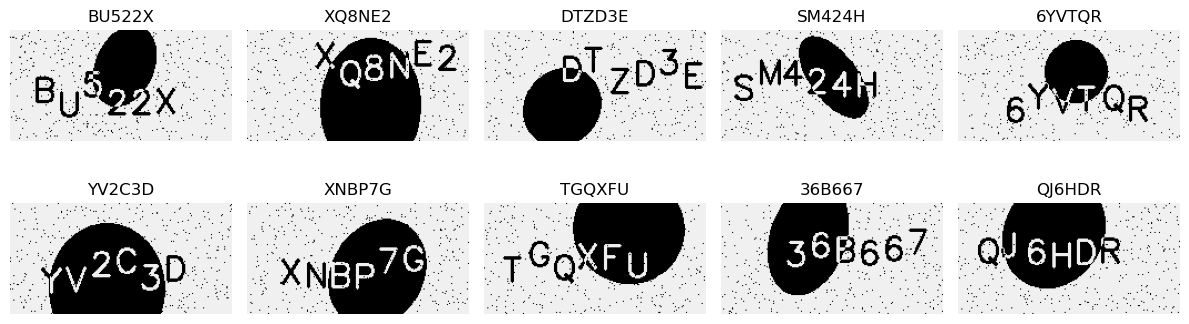

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(12, 4))

for i, ax in enumerate(axes.flat):
    img_name = df.iloc[i]['image']
    label = df.iloc[i]['text']

    img = Image.open(os.path.join(train_dir, img_name))

    ax.imshow(img, cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
missing_files = df[~df['image'].apply(
    lambda x: os.path.exists(os.path.join(train_dir, x))
)]

print("Missing files:", len(missing_files))
print(missing_files.head(10))

Missing files: 0
Empty DataFrame
Columns: [Unnamed: 0, image, text, label_length]
Index: []


In [12]:
sample_img = Image.open(os.path.join(train_dir, df.iloc[0]['image']))
print("Image size:", sample_img.size)

Image size: (200, 100)


In [13]:
all_text = ''.join(df['text'])

chars = sorted(set(all_text))

print("Unique characters:", chars)
print("Vocabulary size:", len(chars))

Unique characters: ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']
Vocabulary size: 38


In [14]:
from collections import Counter

char_counts = Counter(all_text)

for char, count in sorted(char_counts.items()):
    print(f"{repr(char)} : {count}")

'+' : 1
'-' : 2
'.' : 1
'0' : 2
'1' : 1
'2' : 3926
'3' : 3826
'4' : 3884
'5' : 3832
'6' : 3842
'7' : 3989
'8' : 3811
'9' : 3746
'A' : 3819
'B' : 3805
'C' : 3861
'D' : 3880
'E' : 3966
'F' : 3913
'G' : 3942
'H' : 3845
'J' : 3886
'K' : 3753
'M' : 3926
'N' : 3904
'P' : 3836
'Q' : 3873
'R' : 3883
'S' : 3889
'T' : 3841
'U' : 3812
'V' : 3838
'W' : 3916
'X' : 3956
'Y' : 3936
'Z' : 3860
'a' : 1
'r' : 1


In [15]:
valid_chars = set("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ")

df = df[df['text'].apply(
    lambda x: all(c in valid_chars for c in x)
)].reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (19998, 4)


In [16]:
all_text = ''.join(df['text'])
chars = sorted(set(all_text))

print(chars)
print("Vocabulary size:", len(chars))

['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Vocabulary size: 31


In [17]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [18]:
chars = sorted(set(''.join(df['text'])))

char_to_idx = {char: idx + 1 for idx, char in enumerate(chars)}
idx_to_char = {idx + 1: char for idx, char in enumerate(chars)}

BLANK_IDX = 0

print("Vocabulary:", chars)
print("Vocabulary size:", len(chars))
print("Blank index:", BLANK_IDX)

Vocabulary: ['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Vocabulary size: 31
Blank index: 0


In [19]:
def encode_label(text):
    return [char_to_idx[char] for char in text]


def decode_label(indices):
    return ''.join([idx_to_char[idx] for idx in indices if idx != BLANK_IDX])

In [20]:
sample = df.iloc[0]['text']

encoded = encode_label(sample)
decoded = decode_label(encoded)

print("Original:", sample)
print("Encoded :", encoded)
print("Decoded :", decoded)

Original: BU522X
Encoded : [10, 26, 4, 1, 1, 29]
Decoded : BU522X


In [25]:
transform = transforms.Compose([
    transforms.Resize((64, 200)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [27]:
class OCRDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.image_dir, row['image'])
        image = Image.open(img_path).convert('L')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            encode_label(row['text']),
            dtype=torch.long
        )

        return image, label

In [28]:
dataset = OCRDataset(
    df,
    train_dir,
    transform=transform
)

print("Dataset size:", len(dataset))

Dataset size: 19998


In [29]:
image, label = dataset[0]

print("Image shape:", image.shape)
print("Encoded label:", label)
print("Decoded label:", decode_label(label.tolist()))

Image shape: torch.Size([1, 64, 200])
Encoded label: tensor([10, 26,  4,  1,  1, 29])
Decoded label: BU522X


In [30]:
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [31]:
images, labels = next(iter(loader))

print("Batch image shape:", images.shape)
print("Labels in batch:", len(labels))

Batch image shape: torch.Size([32, 1, 64, 200])
Labels in batch: 32
